In [1]:
from dbm import error
from locale import normalize
from xml.sax.handler import feature_namespaces

import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from numpy.random.mtrand import random
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("kütüphaneler yüklendi")


kütüphaneler yüklendi


In [2]:
# Grafiklerin arka planını daha temiz yapar
sns.set_theme(style="whitegrid")

In [3]:
from IPython.display import display

In [4]:
print("step 1 load dataset")
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"dataset shape: {df.shape[0]} satır, {df.shape[1]} sütun \n ")

display(df.head())

step 1 load dataset
dataset shape: 7043 satır, 21 sütun 
 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("---step 2 Data Profiling")

---step 2 Data Profiling


In [6]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None

In [7]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
print(display(df.isnull().sum()))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

None


In [9]:
df.isnull().sum()["TotalCharges"]

np.int64(0)

In [10]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [11]:
hidden_false = df[df["TotalCharges"] == " "]
print(f"\ icinde sadece bosluk karekteri olsa satır sayısı: {len(hidden_false)}")


\ icinde sadece bosluk karekteri olsa satır sayısı: 11


In [12]:
display(hidden_false[["customerID","tenure","MonthlyCharges","TotalCharges"]])

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [13]:
print("Sözleşme Tipleri (Contract)")
print(df["Contract"].value_counts())

Sözleşme Tipleri (Contract)
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [14]:
print("Ödeme Yöntemleri (PaymentMethod)")
print(df["PaymentMethod"].value_counts())


Ödeme Yöntemleri (PaymentMethod)
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [15]:
print("Hedef Değişken (Churn: İptal Etti mi?) Oranı")
print(df["Churn"].value_counts(normalize=True)*100)


Hedef Değişken (Churn: İptal Etti mi?) Oranı
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [16]:
print("--- step 3 Data Cleaning---")
print("totalcharges sütununu numeric formata çeviriyoruz")
print("\n indeki boşluklar çevrilmeyeceği için Nan olacak")
print(f"\n temizlik öncesi satır sayısı: 7043")

df["TotalCharges"]= pd.to_numeric(df["TotalCharges"],errors="coerce")

df.dropna(inplace=True)

#indeksleri sıfırlayarak sıra numaralarının bozulmasını engelleriz
df.reset_index(drop=True, inplace=True)

print(f"temizlik sonrası satır sayısı: {df.shape[0]}")


--- step 3 Data Cleaning---
totalcharges sütununu numeric formata çeviriyoruz

 indeki boşluklar çevrilmeyeceği için Nan olacak

 temizlik öncesi satır sayısı: 7043
temizlik sonrası satır sayısı: 7032


In [17]:
import matplotlib.pyplot as plt

### EDA — Sözleşme Tipine Göre Churn Dağılımı
Aydan aya sözleşme yapan müşteriler yıllık sözleşmelilere kıyasla çok daha yüksek oranda iptal ediyor mu?

step 4 EDA


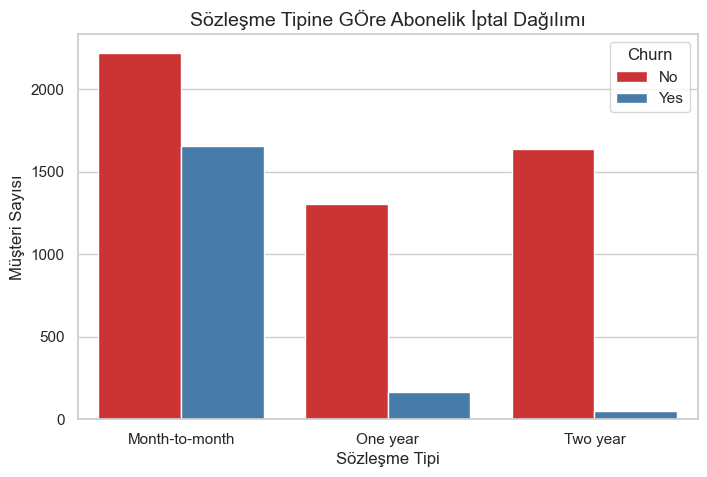

In [18]:
print("step 4 EDA")
#aydan aya mı yoksa yıllık sözleşme mi yapılıyor bu iptal oranını nasıl etkiliyor

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set1")
plt.title("Sözleşme Tipine GÖre Abonelik İptal Dağılımı", fontsize=14)
plt.ylabel("Müşteri Sayısı")
plt.xlabel("Sözleşme Tipi")
plt.show()


### EDA — Aylık Ücretin Churn Üzerindeki Etkisi
Yüksek fatura ödeyen müşteriler daha mı fazla iptal ediyor?

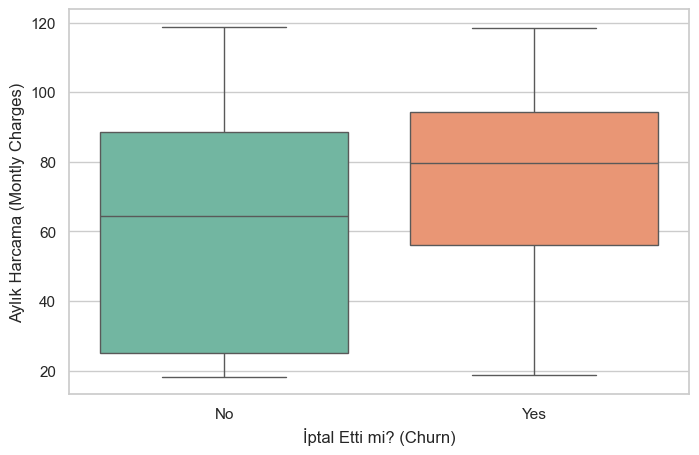

In [19]:
# Aylık Ücretin iptallere etkisi
#Aylık ödenen fatura tutarı arttıkça kullanıcılar kaçıyor mu?

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2")
plt.ylabel("Aylık Harcama (Montly Charges)")
plt.xlabel("İptal Etti mi? (Churn)")
plt.show()

Yapılan analizde, yüksek aylık ücretlerin müşteri kaybı (churn) üzerinde doğrudan ve güçlü bir etkisi olduğu tespit edilmiştir. İptal eden müşterilerin aylık harcama dağılımı, mevcut müşterilere kıyasla çok daha yüksek seviyelerde yoğunlaşmaktadır. Şirket, yüksek fatura ödeyen (örneğin 70 birim ve üzeri) müşterileri kaybetmemek adına bu segmente özel sadakat kampanyaları, indirimler veya ek avantajlar sunmayı değerlendirmelidir.

In [20]:
print("step 5 encoding")
#target olan churn 1 ve 0 yapmalıyız
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

#diğer ikili içeren sutunlar içinde 1-0 uygulayalım
ikili_sutunlar = ["Partner", "Dependents", "PhoneService","PaperlessBilling"]
for col in ikili_sutunlar:
    df[col] = df[col].map({"Yes":1,"No":0})

#çok seçenekli olanları ise dummy uygulayacağız
#Müşteri Id algortitma için anlamsız olacağından sileriz
df_processed = pd.get_dummies(df.drop("customerID", axis=1), drop_first=True)

print("encoding - dummy işlemleri uygulandı")
df_processed.head()
display(df_processed.head())


step 5 encoding
encoding - dummy işlemleri uygulandı


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


### Müşteri Segmentasyonu (K-Means Kümeleme)
SubSmart uygulamasında kullanıcılara özel bildirimler atmak istiyoruz. Ama elimizde 7000 kişi var. Bunları harcama ve sadakatlerine göre mantıklı gruplara ayırabilir miyiz?

Bunun için kullanıcıların tenure (Sistemde kalma süresi/ay) ve MonthlyCharges (Aylık Fatura) değerlerine bakarız

In [21]:
from sklearn.preprocessing import StandardScaler
#scaling yapacağız iki farklı şey algoritmada yanılmasın diye

print("kullanacağımız sutunlar tenure ve monthly charges ")
kumeleme_verisi = df[["tenure", "MonthlyCharges"]]

#standartlaştırma ortalamayı 0 standart sapmayı 1 yapma işlemi
scaler = StandardScaler()
kumeleme_verisi_scaled = scaler.fit_transform(kumeleme_verisi)

print("veriler aynı ölçü birimine getirildi")

kullanacağımız sutunlar tenure ve monthly charges 
veriler aynı ölçü birimine getirildi


### Elbow Method
müşterileri kaç gruba böleceğimi bilmiyorum bu yüzden algoritmayı 1 den 10 a kadar tüm küme sayıları için çalıştırıp hatanın nerede kırıldığını gözlemleyeceğim

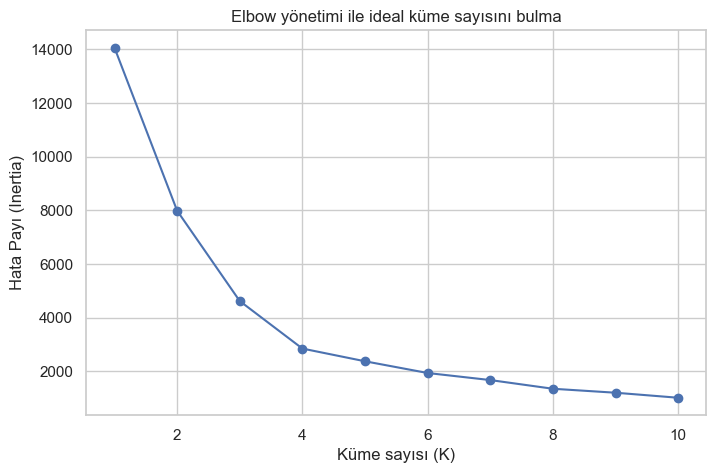

In [22]:
from sklearn.cluster import KMeans
hata_kareler_toplami = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(kumeleme_verisi_scaled)
    hata_kareler_toplami.append(kmeans.inertia_) #inertia_ hata payıdır

#graphic
plt.figure(figsize=(8,5))
plt.plot(range(1,11), hata_kareler_toplami, marker="o", linestyle="-")
plt.title("Elbow yönetimi ile ideal küme sayısını bulma")
plt.xlabel("Küme sayısı (K)")
plt.ylabel("Hata Payı (Inertia)")
plt.show()

In [23]:
print("müşterileri 3 gruba ayıracağız")
print("\n K=3 ile modeli kuracağız")
kmeans = KMeans(n_clusters = 3, random_state = 42)
kume_tahminleri = kmeans.fit_predict(kumeleme_verisi_scaled)

#hangi müşterinin hangi kümeye düştüğünü orijinal veriye ekleyelim
df["Musteri_Segmenti"] = kume_tahminleri

segment_isimleri = {
    0:"sadık müşteriler",
    1:"standart - düşük bütçeliler",
    2:"yeni & riskli (yüksek harcama)"
}

df["Segment_Adi"]= df["Musteri_Segmenti"].map(segment_isimleri)

#kümelerin özelliklerini de görmemiz lazım
segment_ozet = df.groupby("Segment_Adi")[["tenure","MonthlyCharges"]].mean().round(2)
display(segment_ozet)



müşterileri 3 gruba ayıracağız

 K=3 ile modeli kuracağız


,tenure,MonthlyCharges
Segment_Adi,,
sadık müşteriler,57.95,89.01
standart - düşük bütçeliler,29.41,26.49
yeni & riskli (yüksek harcama),12.59,74.99


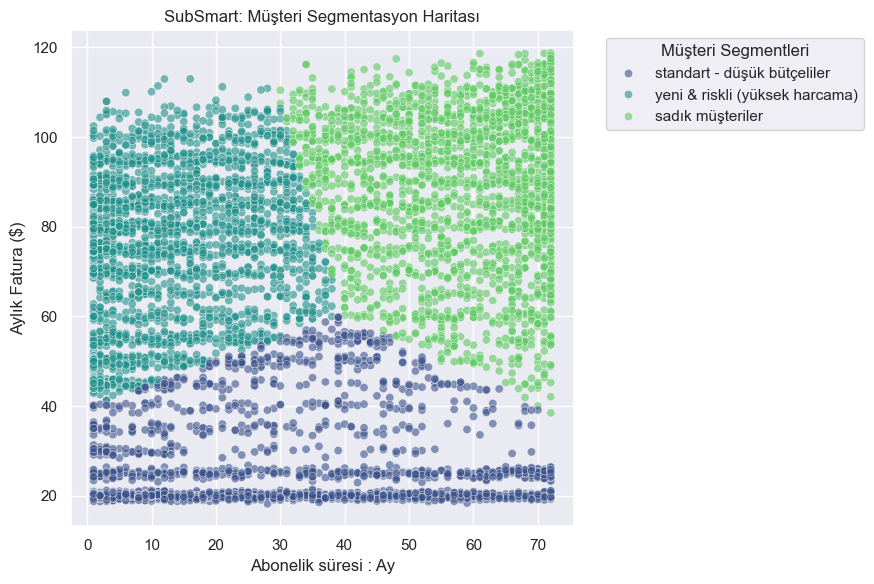

In [53]:
plt.figure(figsize=(9,6))
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Segment_Adi",data=df, palette="viridis", alpha=0.6)
plt.title("SubSmart: Müşteri Segmentasyon Haritası")
plt.xlabel("Abonelik süresi : Ay")
plt.ylabel("Aylık Fatura ($)")
plt.legend(title = "Müşteri Segmentleri", bbox_to_anchor=(1.05, 1),loc = "upper left")
plt.tight_layout()
plt.show()



### KÜMELEME KALİTE METRİĞİ — Silhouette Score
K-Means'in oluşturduğu kümelerin ne kadar iyi ayrıştığını ölçer
-1 ile 1 arasında, 1'e yakın = kümeler birbirinden iyi ayrışmış

In [25]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(kumeleme_verisi_scaled, kume_tahminleri)
inertia = kmeans.inertia_

print("=== KÜMELEME KALİTE METRİKLERİ ===")
print(f"Silhouette Score : {silhouette:.3f}  (1'e yakın = iyi ayrışma)")
print(f"SSE (Inertia)    : {inertia:.2f}")

print("\nYorum:")
if silhouette > 0.5:
    print("  → Kümeler birbirinden iyi ayrışmış, segmentasyon başarılı.")
elif silhouette > 0.3:
    print("  → Makul düzeyde ayrışma, segmentler anlamlı ama örtüşme var.")
else:
    print("  → Zayıf ayrışma, kümeler iç içe geçmiş olabilir.")

=== KÜMELEME KALİTE METRİKLERİ ===
Silhouette Score : 0.447  (1'e yakın = iyi ayrışma)
SSE (Inertia)    : 4615.07

Yorum:
  → Makul düzeyde ayrışma, segmentler anlamlı ama örtüşme var.


### Apriori (birliktelik kuralları)
SubSmart uygulamasında kullanıcıya "şu aboneliği iptal et sana şu ikili paketi önerelim " demek istiyoruz ama kullanıcıların neyi ne ile birlikte tercih ettiğini biilmiyoruz

***orijinal verideki abonelik servislerini (OnlineSecurity, TechSupport, StreamingTV vs.) bulup, sadece onları içeren yeni bir tablo (sepet) yapmalıyız.***

In [26]:
#sadece dijital servisleri içeren sütunları filtreleyelim
servis_sutunları = [col for col in df_processed.columns if "Yes" in col and col not in ["Churn"]]

#sepet oluşturma
sepet = df_processed[servis_sutunları].astype(bool)

display(sepet.head(3))


,MultipleLines_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,False,False,True,False,False,False,False
1,False,True,False,True,False,False,False
2,False,True,True,False,False,False,False


In [27]:
#%10 (min_support=0.1) ihtimalle birlikte görülen ikilileri/üçlüleri bul

from mlxtend.frequent_patterns import apriori, association_rules

print("sık görülen servis kombinasyonları")
popular_combinations = apriori(sepet,min_support=0.1, use_colnames=True)

print("confidence en az 50 olanları baktık")
rules = association_rules(popular_combinations,metric="confidence", min_threshold=0.5, num_itemsets =2)

print("en yüksek lift birlikte alınma gücü değerine göre sıralayalım ve ilk 5 kurala bakalım ")
strong_rules = rules.sort_values(by="lift", ascending=False).head(5)

display(strong_rules[["antecedents","consequents","support","confidence","lift"]])


sık görülen servis kombinasyonları
confidence en az 50 olanları baktık
en yüksek lift birlikte alınma gücü değerine göre sıralayalım ve ilk 5 kurala bakalım 


,antecedents,consequents,support,confidence,lift
118,"frozenset({TechSupport_Yes, StreamingMovies_Yes})","frozenset({DeviceProtection_Yes, StreamingTV_Y...",0.100256,0.574104,2.582918
116,"frozenset({TechSupport_Yes, StreamingTV_Yes})","frozenset({DeviceProtection_Yes, StreamingMovi...",0.100256,0.580247,2.559784
111,"frozenset({OnlineBackup_Yes, StreamingMovies_Y...","frozenset({DeviceProtection_Yes, StreamingTV_Y...",0.105233,0.532757,2.396897
109,"frozenset({OnlineBackup_Yes, StreamingTV_Yes})","frozenset({DeviceProtection_Yes, StreamingMovi...",0.105233,0.532374,2.348591
104,"frozenset({MultipleLines_Yes, StreamingMovies_...","frozenset({DeviceProtection_Yes, StreamingTV_Y...",0.117321,0.518542,2.332940


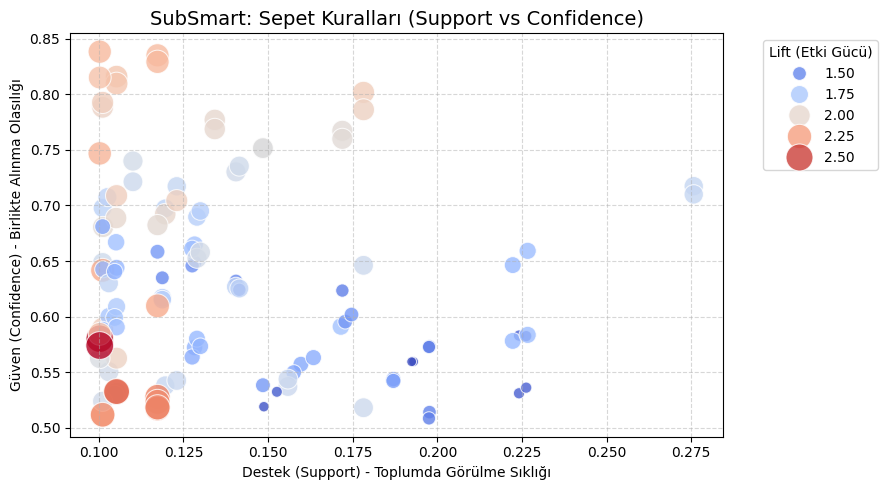

In [58]:
plt.figure(figsize=(9, 5))

# X ekseni: Support (Ne kadar sık görülüyor), Y ekseni: Confidence (Ne kadar güvenilir kural)
# Baloncuk büyüklüğü ve rengi: Lift (Kuralın etki gücü)
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift",
                data=rules, palette="coolwarm", sizes=(50, 400), alpha=0.8)

plt.title('SubSmart: Sepet Kuralları (Support vs Confidence)', fontsize=14)
plt.xlabel('Destek (Support) - Toplumda Görülme Sıklığı')
plt.ylabel('Güven (Confidence) - Birlikte Alınma Olasılığı')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift (Etki Gücü)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### APRİORİ — En Güçlü 5 Kural Tablosu
 Support, Confidence ve Lift değerleriyle raporlama

In [29]:
top5 = rules.sort_values("lift", ascending=False).head(5).copy()

# Frozenset'leri okunabilir stringe çevir
top5["antecedents"] = top5["antecedents"].apply(lambda x: ", ".join(list(x)))
top5["consequents"] = top5["consequents"].apply(lambda x: ", ".join(list(x)))

top5_goster = top5[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
top5_goster.columns = ["Eğer (Antecedent)", "O Zaman (Consequent)", "Support", "Confidence", "Lift"]
top5_goster = top5_goster.reset_index(drop=True)
top5_goster.index += 1

# Sayıları yuvarla
top5_goster["Support"] = top5_goster["Support"].round(3)
top5_goster["Confidence"] = top5_goster["Confidence"].round(3)
top5_goster["Lift"] = top5_goster["Lift"].round(3)

print("=== EN GÜÇLÜ 5 BİRLİKTELİK KURALI (Lift'e Göre) ===\n")
display(top5_goster)

print("\nYorum:")
print(f"  En güçlü kural Lift = {top5_goster['Lift'].max():.3f}")
print(f"  → Bu servisler rastgele beklentiden {top5_goster['Lift'].max():.1f}x daha sık birlikte alınıyor.")

=== EN GÜÇLÜ 5 BİRLİKTELİK KURALI (Lift'e Göre) ===



,Eğer (Antecedent),O Zaman (Consequent),Support,Confidence,Lift
1,"TechSupport_Yes, StreamingMovies_Yes","DeviceProtection_Yes, StreamingTV_Yes",0.100,0.574,2.583
2,"TechSupport_Yes, StreamingTV_Yes","DeviceProtection_Yes, StreamingMovies_Yes",0.100,0.580,2.560
3,"OnlineBackup_Yes, StreamingMovies_Yes","DeviceProtection_Yes, StreamingTV_Yes",0.105,0.533,2.397
4,"OnlineBackup_Yes, StreamingTV_Yes","DeviceProtection_Yes, StreamingMovies_Yes",0.105,0.532,2.349
5,"MultipleLines_Yes, StreamingMovies_Yes","DeviceProtection_Yes, StreamingTV_Yes",0.117,0.519,2.333



Yorum:
  En güçlü kural Lift = 2.583
  → Bu servisler rastgele beklentiden 2.6x daha sık birlikte alınıyor.


### APRİORİ NETWORK GRAFİĞİ
Servisler arası birliktelik ilişkilerini ağ yapısı olarak görselleştirilmesi

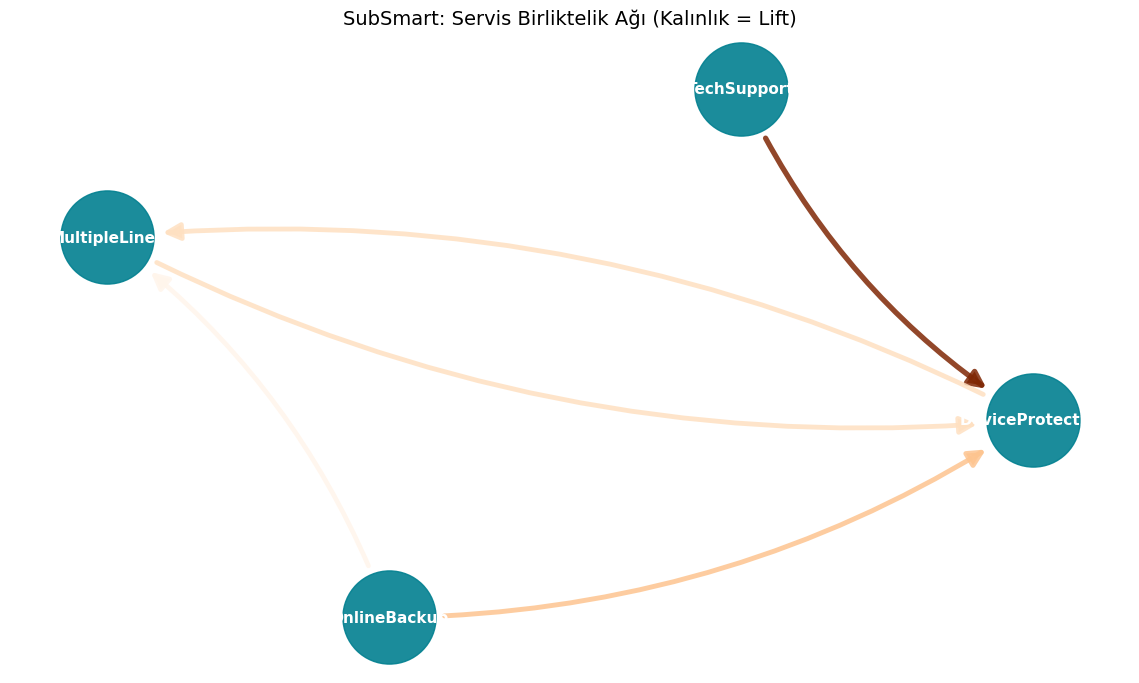

In [65]:
import networkx as nx

top_rules = rules.sort_values("lift", ascending=False).head(10).copy()

def ilk_servis(frozen):
    s = list(frozen)[0]
    return s.replace("_Yes","").replace("InternetService_","").replace("PaymentMethod_","")

top_rules["ant_str"] = top_rules["antecedents"].apply(ilk_servis)
top_rules["con_str"] = top_rules["consequents"].apply(ilk_servis)

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    G.add_edge(row["ant_str"], row["con_str"], weight=row["lift"])

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")  # beyaz arka plan
pos = nx.spring_layout(G, seed=42, k=5)
pos = {k: (v[0]*0.55, v[1]*0.55) for k, v in pos.items()}

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=4500,
                       node_color="#028090", alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11,
                        font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos,
                       width=[w * 1.5 for w in edge_weights],
                       edge_color=edge_weights,
                       edge_cmap=plt.cm.Oranges,
                       arrows=True, arrowsize=25, alpha=0.85,
                       connectionstyle="arc3,rad=0.15",
                       min_source_margin=40, min_target_margin=40,
                       ax=ax)

ax.set_title("SubSmart: Servis Birliktelik Ağı (Kalınlık = Lift)", fontsize=14)
ax.axis("off")
ax.set_facecolor("white")  # eksen arka planı da beyaz
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.savefig("apriori_network.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

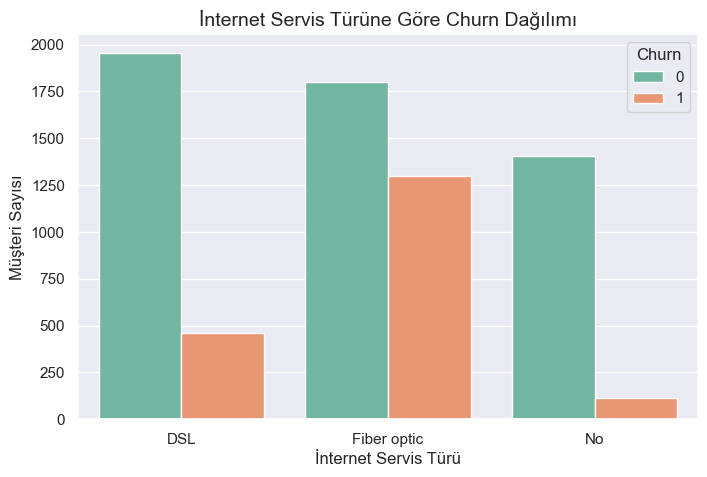


 İnternet Servis Türüne Göre Churn Oranı (%): 
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn",data=df, palette="Set2")
plt.title("İnternet Servis Türüne Göre Churn Dağılımı", fontsize=14)
plt.ylabel("Müşteri Sayısı")
plt.xlabel("İnternet Servis Türü")
plt.show()

print("\n İnternet Servis Türüne Göre Churn Oranı (%): ")
print((df.groupby("InternetService")["Churn"].mean()*100).round(1))

### SEGMENT CHURN TABLOSU
K-means segmentlerinin churn oranlarını gösterir
pipeline mantığını destekler soru -> segmentler churnu etkiliyor mu


In [32]:
print("Müşteri Segmentine Göre Churn Oranı (%):")
print((df.groupby("Segment_Adi")["Churn"].mean()*100).round(1))

print("\n Müşteri Segmentine Göre Müşteri Sayısı ve Churn:")
print(df.groupby("Segment_Adi")["Churn"].agg(["count","sum","mean"]).round(2))


Müşteri Segmentine Göre Churn Oranı (%):
Segment_Adi
sadık müşteriler                  15.6
standart - düşük bütçeliler       12.4
yeni & riskli (yüksek harcama)    47.7
Name: Churn, dtype: float64

 Müşteri Segmentine Göre Müşteri Sayısı ve Churn:
                                count   sum  mean
Segment_Adi                                      
sadık müşteriler                 2282   357  0.16
standart - düşük bütçeliler      2137   266  0.12
yeni & riskli (yüksek harcama)   2613  1246  0.48


### PIPELINE BAĞLANTI KATMANI
Apriori ve K-means çıktılarını RF _e feature olarak hazırlama

In [33]:
print("En güçlü 5 kural (Lifte_e göre ):")
print(rules.sort_values("lift",ascending=False)[
    ["antecedents","consequents","support","confidence","lift"]
      ].head(5).to_string())

En güçlü 5 kural (Lifte_e göre ):
                                             antecedents                                             consequents   support  confidence      lift
118    frozenset({TechSupport_Yes, StreamingMovies_Yes})      frozenset({DeviceProtection_Yes, StreamingTV_Yes})  0.100256    0.574104  2.582918
116        frozenset({TechSupport_Yes, StreamingTV_Yes})  frozenset({DeviceProtection_Yes, StreamingMovies_Yes})  0.100256    0.580247  2.559784
111   frozenset({OnlineBackup_Yes, StreamingMovies_Yes})      frozenset({DeviceProtection_Yes, StreamingTV_Yes})  0.105233    0.532757  2.396897
109       frozenset({OnlineBackup_Yes, StreamingTV_Yes})  frozenset({DeviceProtection_Yes, StreamingMovies_Yes})  0.105233    0.532374  2.348591
104  frozenset({MultipleLines_Yes, StreamingMovies_Yes})      frozenset({DeviceProtection_Yes, StreamingTV_Yes})  0.117321    0.518542  2.332940


### PIPELINE - Apriori Kurallarından Binary Feature Üretimi
Güçlü kurallar yeni sütünlar RF 'e eklenecek

In [34]:
#kural 1 TechSupport + StreamingMovies + DeviceProtection + StreamingTV (lift: 2.58)

df["combo_TechSupport_Streaming"]= (
(df["TechSupport"]== "Yes") &
(df["StreamingMovies"] == "Yes") &
(df["DeviceProtection"] == "Yes") &
(df["StreamingTV"] == "Yes")
).astype(int)

#kural 2 OnlineBackup + StreamingMovies + DeviceProtection + StreamingTV (lift: 2.39)
df["combo_Backup_Streaming"] = (
(df["OnlineBackup"] == "Yes") &
(df["StreamingMovies"] == "Yes") &
(df["DeviceProtection"] == "Yes") &
(df["StreamingTV"] == "Yes")
).astype(int)

#kural3: MultipleLines + StreamingMovies + DeviceProtection +StreamingTV ( lift:2.33)
df["combo_MultipleLines_Streaming"] = (
    (df["MultipleLines"] == "Yes") &
    (df["StreamingMovies"] == "Yes") &
    (df["DeviceProtection"] == "Yes") &
    (df["StreamingTV"] == "Yes")
).astype(int)

print("Binary feature'lar oluşturuldu:")
print(f"combo_TechSupport_Streaming : {df['combo_TechSupport_Streaming'].sum()} müşteri")

print(f"combo_Backup_Streaming : {df['combo_Backup_Streaming'].sum()} müşteri")

print(f"combo_MultipleLines_Streaming: {df["combo_MultipleLines_Streaming"].sum()} müşteri")


Binary feature'lar oluşturuldu:
combo_TechSupport_Streaming : 705 müşteri
combo_Backup_Streaming : 740 müşteri
combo_MultipleLines_Streaming: 825 müşteri


### PIPELINE - Zenginleştirilmiş Feature Set Oluşturma
cluster_id + Apriori combo feature'ları df_processede'e eklenir

In [35]:
#df_processed'e pipeline feature'larını ekleriz
df_processed["Musteri_Segmenti"]  = df["Musteri_Segmenti"]

df_processed["combo_TechSupport_Streaming"] = df["combo_TechSupport_Streaming"]

df_processed["combo_Backup_Streaming"] = df["combo_Backup_Streaming"]

df_processed["combo_MultipleLines_Streaming"] = df["combo_MultipleLines_Streaming"]

#hedeh değişken
X = df_processed.drop("Churn", axis=1)
y = df_processed["Churn"]

print(f"Feature sayısı (orijinal): {len(df_processed.drop('Churn', axis=1).columns) - 4}")
print(f"Feature sayısı (pipeline): {len(X.columns)}")
print(f"\nEklenen pipeline feature'ları:")
print("  - Musteri_Segmenti (K-Means çıktısı)")
print("  - combo_TechSupport_Streaming (Apriori kural 1)")
print("  - combo_Backup_Streaming (Apriori kural 2)")
print("  - combo_MultipleLines_Streaming (Apriori kural 3)")



Feature sayısı (orijinal): 30
Feature sayısı (pipeline): 34

Eklenen pipeline feature'ları:
  - Musteri_Segmenti (K-Means çıktısı)
  - combo_TechSupport_Streaming (Apriori kural 1)
  - combo_Backup_Streaming (Apriori kural 2)
  - combo_MultipleLines_Streaming (Apriori kural 3)


### BASELINE MODEL - Desicison Tree
karşılaştırma referansı: sadece orijinal featurelar

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [37]:
#Train / Test Split - %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Seti: {X_train.shape[0]} satır")
print(f"Test Seti: {X_test.shape[0]} satır")
print(f" Test churn oranı: %{y_test.mean()*100:.1f}")

#Baseline Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n Baseline - Decision Tree")
print(classification_report(y_test, y_pred_dt,target_names=["Kaldı","İptal"]))
print(f"ROC-AUC: {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.3f}")

Eğitim Seti: 5625 satır
Test Seti: 1407 satır
 Test churn oranı: %26.6

 Baseline - Decision Tree
              precision    recall  f1-score   support

       Kaldı       0.81      0.79      0.80      1033
       İptal       0.46      0.50      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407

ROC-AUC: 0.646


- Precision (Keskinlik): Model "İptal edecek" dediğinde, bunların yüzde kaçı gerçekten iptal etti? (Yalancı çobanlık yapıyor mu?)

- Recall (Duyarlılık): Gerçekten iptal edenlerin toplamda yüzde kaçını yakalayabildi? (Kaçan balık büyük mü?)

- F1-Score: Yukarıdaki ikisinin dengeli bir ortalamasıdır.
 - AUC Skoru modelin "Kalacak" müşteri ile "İptal edecek" müşteriyi birbirinden ayırt etme kabiliyetidir.

### PIPELINE MODEL - Random Forest
K-Means + Apriori feature'larıyla zenginleştirilmiş set
class_weight = balanced ile imbalanced problemi çözülüyor

In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("PIPELINE - Random Forest")

print(classification_report(y_test, y_pred_rf, target_names = ["Kaldı", "İptal"]))

print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

#karşılaştırma özeti
print("\n Karşılaştırma Özeti")
from sklearn.metrics import f1_score, recall_score

print(f"{'Model':<25} {'F1-İptal':>10} {'Recall-İptal':>14} {'ROC-AUC':>10}")
print("-" * 62)
print(f"{'Baseline DT':<25} {f1_score(y_test, y_pred_dt):.3f}{'':>7} {recall_score(y_test, y_pred_dt):.3f}{'':>10} {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.3f}")
print(f"{'Pipeline RF':<25} {f1_score(y_test, y_pred_rf):.3f}{'':>7} {recall_score(y_test, y_pred_rf):.3f}{'':>10} {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

PIPELINE - Random Forest
              precision    recall  f1-score   support

       Kaldı       0.83      0.90      0.86      1033
       İptal       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.818

 Karşılaştırma Özeti
Model                       F1-İptal   Recall-İptal    ROC-AUC
--------------------------------------------------------------
Baseline DT               0.483        0.503           0.646
Pipeline RF               0.553        0.487           0.818


### ROC CURVE — Baseline DT vs Pipeline RF Karşılaştırması

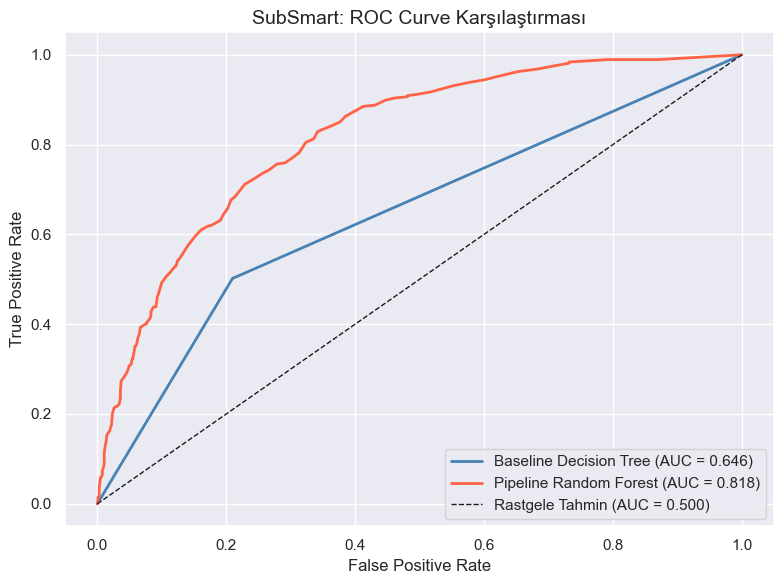

In [39]:
from sklearn.metrics import roc_curve, auc

# DT için ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])
auc_dt = auc(fpr_dt, tpr_dt)

# RF için ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color="steelblue", linewidth=2,
         label=f"Baseline Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, color="tomato", linewidth=2,
         label=f"Pipeline Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], "k--", linewidth=1, label="Rastgele Tahmin (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SubSmart: ROC Curve Karşılaştırması", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Mavi çizgi standart verilerle elde edebileceğimiz sonuçtu. Ancak kırmızı çizgi, benim geliştirdiğim SubSmart Pipeline katmanıyla ulaştığımız noktadır. Modelimiz artık müşterileri birbirinden ayırma konusunda %80'in üzerinde bir isabet kabiliyetine sahip.

### PRECISION-RECALL CURVE — Baseline DT vs Pipeline RF
Sınıf dengesizliğinde ROC'tan daha bilgilendirici metrik

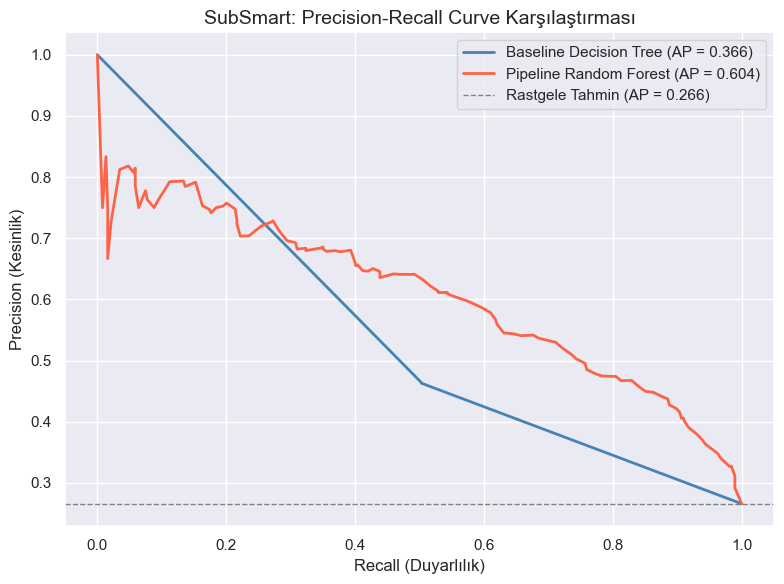

In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# DT için PR
precision_dt, recall_dt, _ = precision_recall_curve(y_test, dt.predict_proba(X_test)[:,1])
ap_dt = average_precision_score(y_test, dt.predict_proba(X_test)[:,1])

# RF için PR
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf.predict_proba(X_test)[:,1])
ap_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:,1])

# Baseline (rastgele) = churn oranı
baseline_pr = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall_dt, precision_dt, color="steelblue", linewidth=2,
         label=f"Baseline Decision Tree (AP = {ap_dt:.3f})")
plt.plot(recall_rf, precision_rf, color="tomato", linewidth=2,
         label=f"Pipeline Random Forest (AP = {ap_rf:.3f})")
plt.axhline(y=baseline_pr, color="gray", linestyle="--", linewidth=1,
            label=f"Rastgele Tahmin (AP = {baseline_pr:.3f})")
plt.xlabel("Recall (Duyarlılık)")
plt.ylabel("Precision (Kesinlik)")
plt.title("SubSmart: Precision-Recall Curve Karşılaştırması", fontsize=14)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

1. Eğrilerin Dili: Ne Anlatıyor?
Y ekseni (Precision): Modelin "İptal edecek" dediği tahminlerin ne kadarının gerçekten iptal ettiği (İsabet oranı).

X ekseni (Recall): Gerçekten iptal eden müşterilerin toplamda yüzde kaçını yakalayabildiğin (Kapsama oranı).

İdeal Model: Grafiğin sağ üst köşesine (1.0, 1.0) en yakın olan modeldir. Yani hem herkesi yakalayan hem de hiç yanlış alarm vermeyen model.

2. Karşılaştırma Analizi
Baseline Decision Tree (AP = 0.366): Mavi çizgi oldukça zayıf.ROC eğrisinde fena durmuyordu ama bu eğri bize gerçeği söylüyor: "Recall arttıkça (daha fazla churn yakalamaya çalıştıkça) isabet oranı (Precision) hızla çakılıyor."

Pipeline Random Forest (AP = 0.604): Kırmızı eğri çok daha yukarıda ve kararlı.

AP (Average Precision) Skorundaki Sıçrama: 0.36'dan 0.60'a çıkmak, modelin kalitesini neredeyse iki katına çıkardığını gösterir.

Dayanıklılık: Model, churn edenlerin %60'ını (Recall=0.6) yakalarken bile hala %55-60 civarında bir isabet (Precision) sunabiliyor. Bu, pazarlama bütçesini çöpe atmamak için harika bir haber.

### CONFUSION MATRIX- Baseline DT vs Pipeline RF


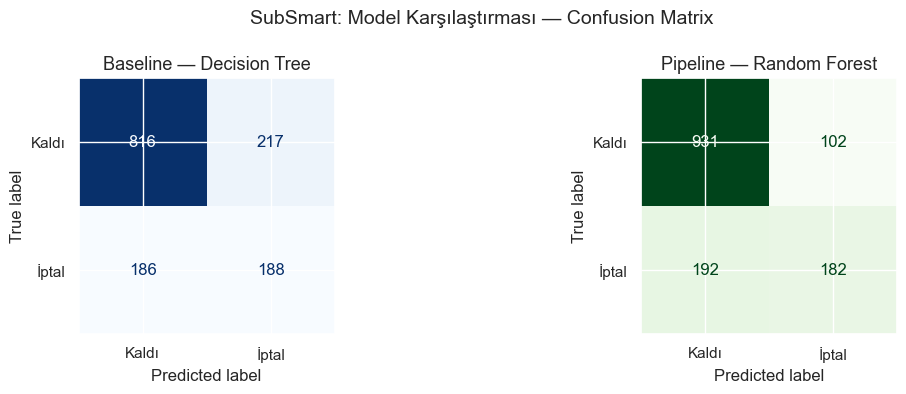

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["Kaldı", "İptal"],
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Baseline — Decision Tree", fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Kaldı", "İptal"],
    ax=axes[1], colorbar=False, cmap="Greens"
)
axes[1].set_title("Pipeline — Random Forest", fontsize=13)

plt.suptitle("SubSmart: Model Karşılaştırması — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

 ### ANOMALİ TESPİTİ - Isolation Forest
 Zombi Abonelik: kendi grubuna göre anormal fatura ödeyen müşteriler

In [42]:
from sklearn.ensemble import IsolationForest

In [43]:
iso = IsolationForest(contamination=0.05, random_state=42)
df["anomali_skoru"] = iso.fit_predict(df[["MonthlyCharges", "tenure"]])

#-1 = anormal (zombi), 1 = normal
zombi = df[df["anomali_skoru"] == -1]
normal = df[df["anomali_skoru"] == 1]

print(f"Toplam müşteri : {len(df)}")
print(f"Normal müşteri : {len(normal)}")
print(f"Zombi Abonelik : {len(zombi)}")
print(f"Zombi oranı : {len(zombi)/len(df)*100:.1f}")

print(f"\n Zombi müşterilerinin ortalama aylık ücreti : {zombi["MonthlyCharges"].mean():.2f} $")
print(f"Normal müşterilerin ortalama aylık ücreti: {normal["MonthlyCharges"].mean():.2f} $")


print(f"\n Zombi müşterilerin churn oranı : %{zombi["Churn"].mean()*100:.1f}")
print(f"Normal müşterilerin churn oranı: %{normal["Churn"].mean()*100:.1f}")


Toplam müşteri : 7032
Normal müşteri : 6680
Zombi Abonelik : 352
Zombi oranı : 5.0

 Zombi müşterilerinin ortalama aylık ücreti : 64.64 $
Normal müşterilerin ortalama aylık ücreti: 64.81 $

 Zombi müşterilerin churn oranı : %10.5
Normal müşterilerin churn oranı: %27.4


### ANOMALİ TESPİTİ - Görselleştirme

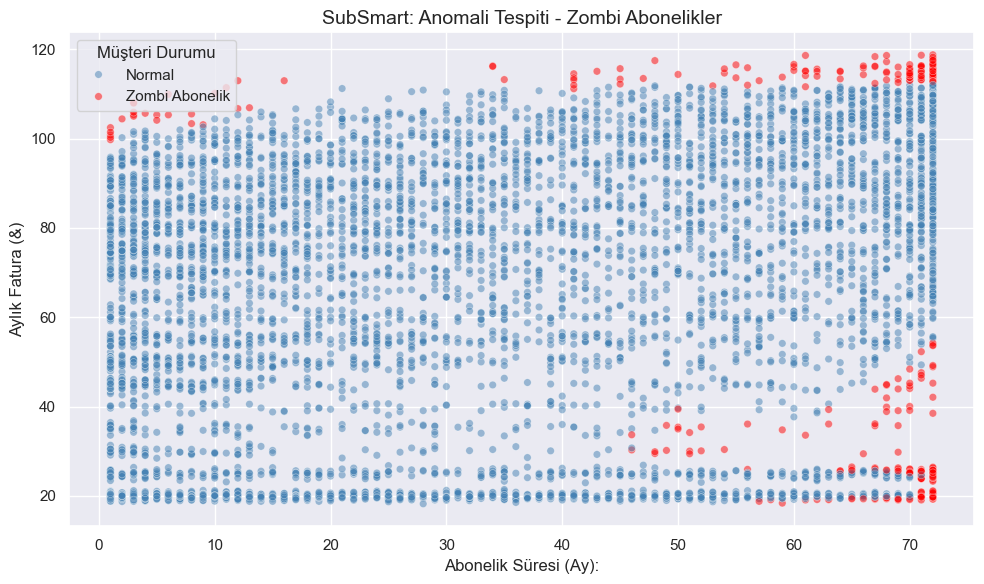

Zombi Aboneliklerin Segment Dağılımı:
Segment_Adi
standart - düşük bütçeliler       176
sadık müşteriler                  151
yeni & riskli (yüksek harcama)     25
Name: count, dtype: int64


In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue=df["anomali_skoru"].map({1:"Normal", -1:"Zombi Abonelik"}),
    data = df,
    palette = {"Normal":"steelblue","Zombi Abonelik":"red"},
    alpha=0.5,
    s=30
)

plt.title("SubSmart: Anomali Tespiti - Zombi Abonelikler", fontsize=14)
plt.xlabel("Abonelik Süresi (Ay):")
plt.ylabel("Aylık Fatura (&)")
plt.legend(title="Müşteri Durumu")
plt.tight_layout()
plt.show()

#Zombi Müşterilerinin segment dağılımı
print("Zombi Aboneliklerin Segment Dağılımı:")
print(df[df["anomali_skoru"] ==-1]["Segment_Adi"].value_counts())

### SİMPSON PARADOKSU ANALİZİ
Genel istatistik vs alt grup gerçeği

In [45]:
print("=" * 50)
print("GENEL CHURN ORANI")
print("=" * 50)
print(f"Tüm müşteriler: %{df['Churn'].mean()*100:.1f}")

print("\n" + "=" * 50)
print("SÖZLEŞME TİPİNE GÖRE CHURN ORANI")
print("=" * 50)
print((df.groupby("Contract")["Churn"].mean()*100).round(1))

print("\n" +"=" * 50)
print("İNTERNET SERVİSİNE GÖRE CHURN ORANI")
print("=" * 50)
print((df.groupby("InternetService")["Churn"].mean()*100).round(1))

print("\n" + "=" * 50)
print("SIMPSON PARADOKSU: FİBER + SÖZLEŞME TİPİ")
print("Fiber optik tek başına riskli görünür")
print("Ama sözleşme tipine göre bakınca tablo değişir")
print("=" * 50)
print((df[df["InternetService"]== "Fiber optic"]
      .groupby("Contract")["Churn"].mean()*100).round(1))


GENEL CHURN ORANI
Tüm müşteriler: %26.6

SÖZLEŞME TİPİNE GÖRE CHURN ORANI
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

İNTERNET SERVİSİNE GÖRE CHURN ORANI
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

SIMPSON PARADOKSU: FİBER + SÖZLEŞME TİPİ
Fiber optik tek başına riskli görünür
Ama sözleşme tipine göre bakınca tablo değişir
Contract
Month-to-month    54.6
One year          19.3
Two year           7.2
Name: Churn, dtype: float64


Fiber optik genel: %41.9 → "Fiber riskli" diye görülüyor ilk başta

Fiber + 2 yıllık sözleşme: %7.2 → aslında en sadık grup

Fiber + month-to-month: %54.6 → asıl risk burada

### SIMPSON PARADOKSU - Görselleştirme

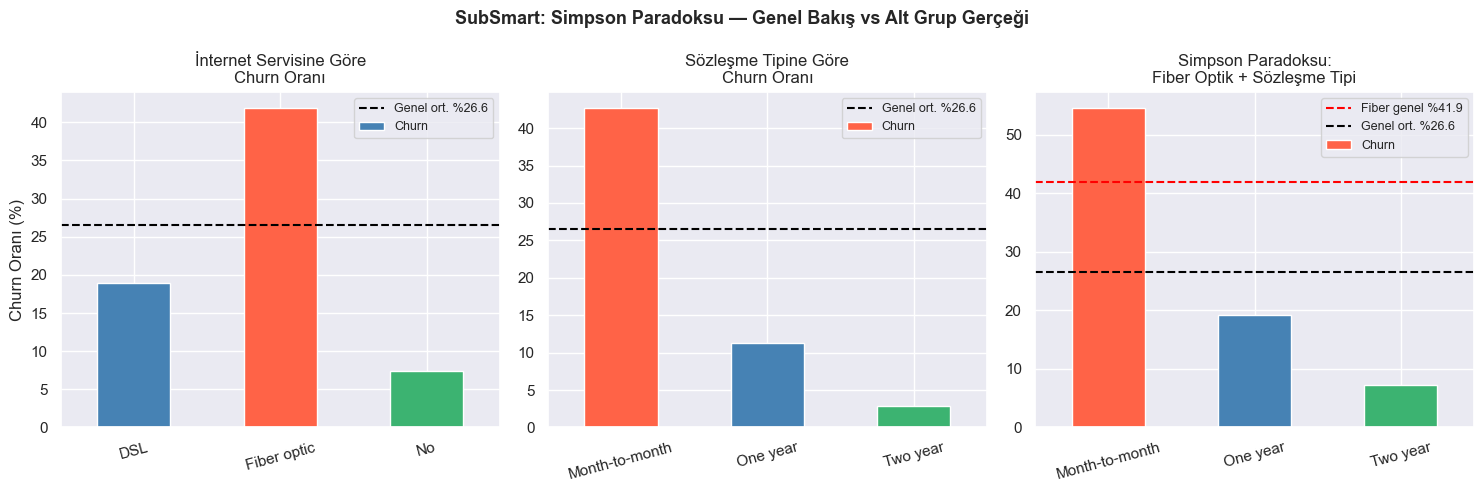

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — Genel ve internet servisine göre
churn_internet = df.groupby("InternetService")["Churn"].mean() * 100
churn_internet.plot(kind="bar", ax=axes[0], color=["steelblue","tomato","mediumseagreen"],
                    edgecolor="white", rot=15)
axes[0].axhline(y=df["Churn"].mean()*100, color="black", linestyle="--", linewidth=1.5,
                label=f"Genel ort. %{df['Churn'].mean()*100:.1f}")
axes[0].set_title("İnternet Servisine Göre\nChurn Oranı", fontsize=12)
axes[0].set_ylabel("Churn Oranı (%)")
axes[0].set_xlabel("")
axes[0].legend(fontsize=9)

# Panel 2 — Sözleşme tipine göre
churn_contract = df.groupby("Contract")["Churn"].mean() * 100
churn_contract.plot(kind="bar", ax=axes[1], color=["tomato","steelblue","mediumseagreen"],
                    edgecolor="white", rot=15)
axes[1].axhline(y=df["Churn"].mean()*100, color="black", linestyle="--", linewidth=1.5,
                label=f"Genel ort. %{df['Churn'].mean()*100:.1f}")
axes[1].set_title("Sözleşme Tipine Göre\nChurn Oranı", fontsize=12)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(fontsize=9)

# Panel 3 — Simpson: Fiber + Sözleşme
churn_fiber = df[df["InternetService"] == "Fiber optic"].groupby("Contract")["Churn"].mean() * 100
churn_fiber.plot(kind="bar", ax=axes[2], color=["tomato","steelblue","mediumseagreen"],
                 edgecolor="white", rot=15)
axes[2].axhline(y=41.9, color="red", linestyle="--", linewidth=1.5,
                label="Fiber genel %41.9")
axes[2].axhline(y=df["Churn"].mean()*100, color="black", linestyle="--", linewidth=1.5,
                label=f"Genel ort. %{df['Churn'].mean()*100:.1f}")
axes[2].set_title("Simpson Paradoksu:\nFiber Optik + Sözleşme Tipi", fontsize=12)
axes[2].set_ylabel("")
axes[2].set_xlabel("")
axes[2].legend(fontsize=9)

plt.suptitle("SubSmart: Simpson Paradoksu — Genel Bakış vs Alt Grup Gerçeği",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### SHAP - Model Yorumlanabilirliği (XAI)
Random Forest neden churn tahmini yapıyor?


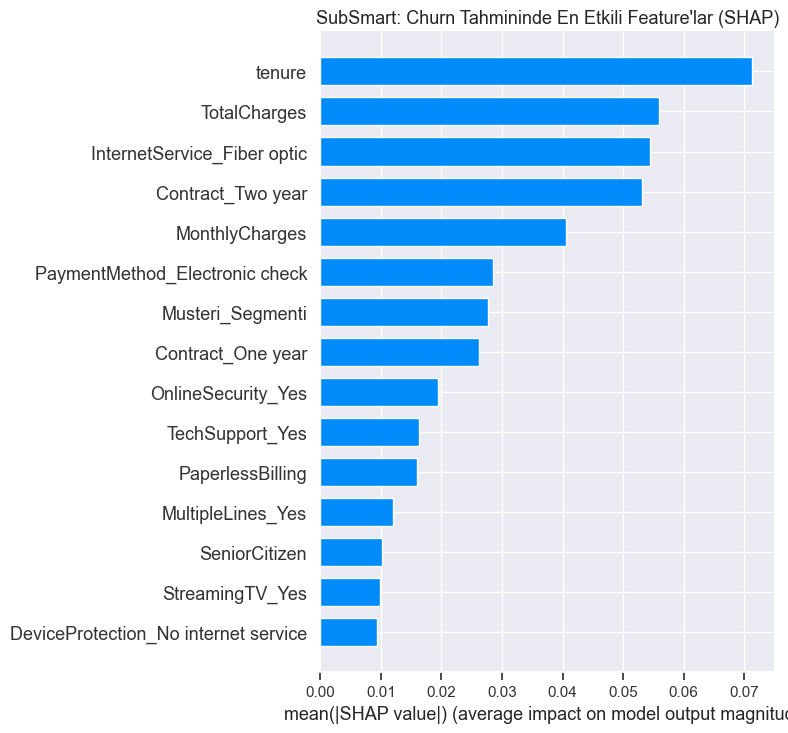

In [47]:
import shap

# SHAP değerlerini hesapla
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary Plot — hangi feature en çok etkiliyor
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],  # İptal sınıfı (1)
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SubSmart: Churn Tahmininde En Etkili Feature'lar (SHAP)", fontsize=13)
plt.tight_layout()
plt.show()

"Modelimiz bir müşterinin gideceğine karar verirken sadece faturaya bakmıyor. Benim oluşturduğum Müşteri Segmentasyonu, modelin karar verme sürecinde en etkili ilk 10 faktörden biri haline geldi. Özellikle Fiber internet ve Sözleşme tipi arasındaki dengeyi modelimiz çok iyi kavramış durumda."

### FEATURE IMPORTANCE — Random Forest Built-in
SHAP ile karşılaştırma için RF'in kendi önem skorları

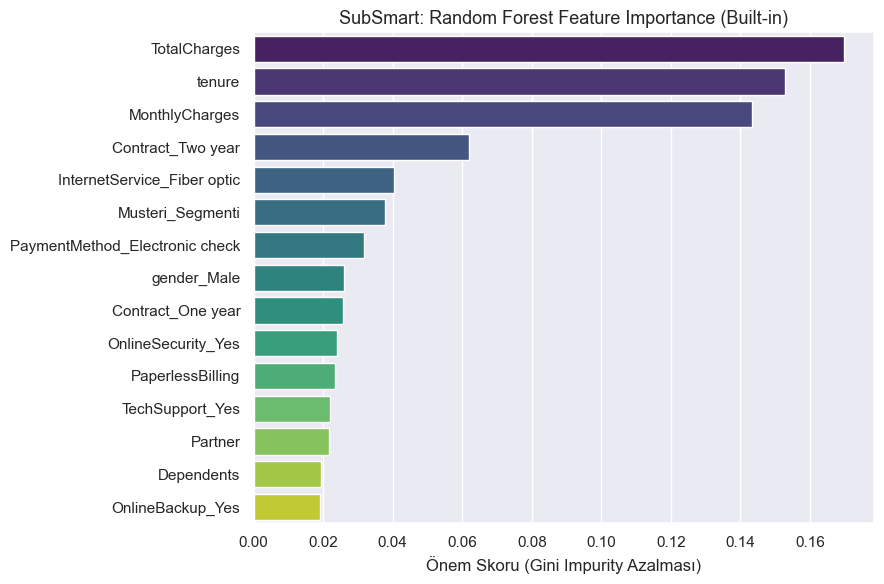


SHAP vs RF Feature Importance Karşılaştırması (Top 5):
Sıra   SHAP                                RF Built-in                        
----------------------------------------------------------------------------
1      tenure                              TotalCharges                       
2      TotalCharges                        tenure                             
3      InternetService_Fiber optic         MonthlyCharges                     
4      Contract_Two year                   Contract_Two year                  
5      MonthlyCharges                      InternetService_Fiber optic        


In [48]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15).reset_index(drop=True)

plt.figure(figsize=(9, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance,
            palette="viridis", edgecolor="white")
plt.title("SubSmart: Random Forest Feature Importance (Built-in)", fontsize=13)
plt.xlabel("Önem Skoru (Gini Impurity Azalması)")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nSHAP vs RF Feature Importance Karşılaştırması (Top 5):")
print(f"{'Sıra':<6} {'SHAP':<35} {'RF Built-in':<35}")
print("-" * 76)
shap_top5 = ["tenure", "TotalCharges", "InternetService_Fiber optic",
             "Contract_Two year", "MonthlyCharges"]
rf_top5 = feature_importance["Feature"].head(5).tolist()
for i, (s, r) in enumerate(zip(shap_top5, rf_top5), 1):
    print(f"{i:<6} {s:<35} {r:<35}")

Bu iki listenin ilk 5'i neredeyse aynı özelliklerden oluşuyor. Bu durum, modelinin tutarlı olduğunu gösterir.
genellikle SHAP sonuçlarına daha çok güvenilir çünkü Yanlılık Yoktur: RF'in kendi skoru, yüksek kardinaliteli (çok fazla farklı değer içeren) sayısal değişkenlere (TotalCharges gibi) bazen hak ettiğinden fazla değer verebilir.

Gerçek Etki: SHAP, modelin çıktısındaki "gerçek değişimi" ölçer.

### SHAP BEESWARM PLOT
Her müşteri için feature etkisi - yön ve dağılım birlikte
Mavi = churn azaltıyor, Kırmızı = churn artırıyor

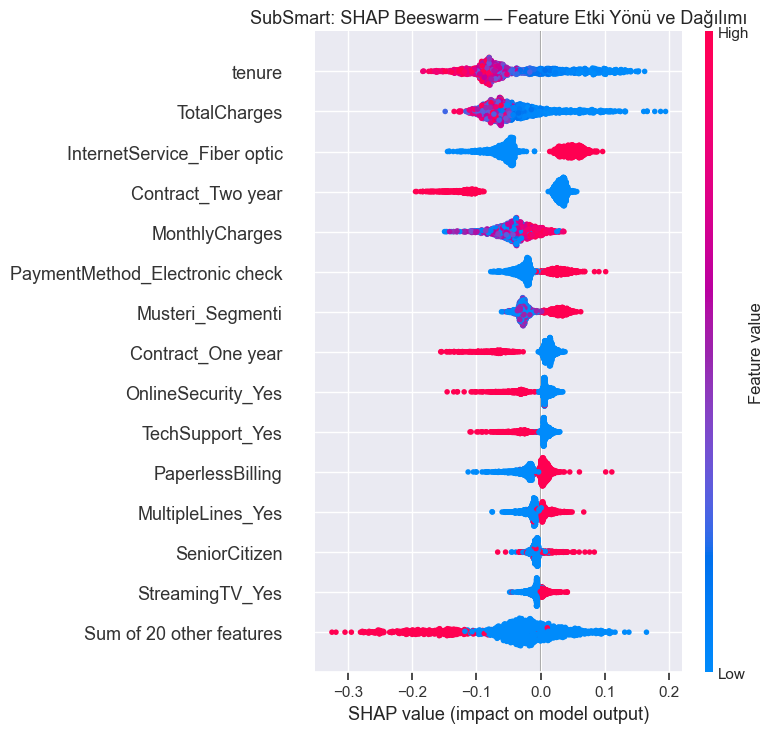

In [49]:
shap_explanation = shap.Explanation(
    values=shap_values[:, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.values,
    feature_names=X_test.columns.tolist()
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("SubSmart: SHAP Beeswarm — Feature Etki Yönü ve Dağılımı", fontsize=13)
plt.tight_layout()
plt.show()

Hoşgeldin Kampanyası: Tenure en büyük riskse, ilk 3 aydaki müşterilere ekstra özen gösterilmeli.

Fiber + Sözleşme Kilidi: Fiber kullananlar (sağda kırmızı) riskliyse, onları acilen 2 yıllık sözleşmeye (solda kırmızı) ikna edecek kampanyalar yapılmalı.

Teknik Destek (TechSupport_Yes): Grafikte TechSupport_Yes kısmında sol tarafta kırmızılar var. Demek ki teknik destek alan müşteri daha sadık kalıyor. Müşterilere teknik desteği bir "ayrıcalık" olarak sunmalıyız.

### GERÇEK ZAMANLI SİMÜLASYON FONKSİYONU
Yeni müşteri girdisi → Churn riski + Segment + Zombi uyarısı
3 modeli birleştiren entegre SubSmart motoru

In [50]:
def subsmart_analiz(musteri_verisi: dict):
    aylik_ucret = musteri_verisi.get("MonthlyCharges", 0)
    sure = musteri_verisi.get("tenure", 0)

    # 1 — Segment tahmini (K-Means)
    veri_scaled = scaler.transform([[sure, aylik_ucret]])
    segment_id = kmeans.predict(veri_scaled)[0]
    segment_isimleri = {
        0: "Sadık Müşteriler",
        1: "Standart - Düşük Bütçeliler",
        2: "Yeni & Riskli (Yüksek Harcama)"
    }
    segment = segment_isimleri.get(segment_id, "Bilinmiyor")

    # 2 — Zombi abonelik tespiti (Isolation Forest)
    anomali = iso.predict([[aylik_ucret, sure]])[0]
    zombi_uyari = "UYARI: Zombi Abonelik Tespit Edildi!" if anomali == -1 else " Normal"

    # 3 — Churn riski (Random Forest)
    bos_satir = pd.DataFrame([{col: 0 for col in X.columns}])
    bos_satir["MonthlyCharges"] = aylik_ucret
    bos_satir["tenure"] = sure
    bos_satir["Musteri_Segmenti"] = segment_id

    churn_olasiligi = rf.predict_proba(bos_satir)[0][1]

    if churn_olasiligi >= 0.6:
        risk = "🔴 YÜKSEK RİSK"
    elif churn_olasiligi >= 0.35:
        risk = "🟡 ORTA RİSK"
    else:
        risk = "🟢 DÜŞÜK RİSK"

    print("=" * 52)
    print("      SubSmart — Müşteri Analiz Raporu")
    print("=" * 52)
    print(f"  Aylık Ücret      : {aylik_ucret} $")
    print(f"  Abonelik Süresi  : {sure} ay")
    print(f"  Müşteri Segmenti : {segment}")
    print(f"  Churn Olasılığı  : %{churn_olasiligi*100:.1f}  →  {risk}")
    print(f"  Zombi Abonelik   : {zombi_uyari}")
    print("=" * 52)

# TEST 1 — Yeni, yüksek ücretli müşteri (riskli profil)
print("TEST 1 — Yeni, yüksek ücretli müşteri:")
subsmart_analiz({"MonthlyCharges": 95, "tenure": 2})

print()

# TEST 2 — Uzun süreli, düşük ücretli müşteri (sadık profil)
print("TEST 2 — Uzun süreli, düşük ücretli müşteri:")
subsmart_analiz({"MonthlyCharges": 25, "tenure": 60})

print()

# TEST 3 — Orta profil
print("TEST 3 — Orta profil:")
subsmart_analiz({"MonthlyCharges": 65, "tenure": 24})

TEST 1 — Yeni, yüksek ücretli müşteri:
      SubSmart — Müşteri Analiz Raporu
  Aylık Ücret      : 95 $
  Abonelik Süresi  : 2 ay
  Müşteri Segmenti : Yeni & Riskli (Yüksek Harcama)
  Churn Olasılığı  : %47.0  →  🟡 ORTA RİSK
  Zombi Abonelik   : ✅ Normal

TEST 2 — Uzun süreli, düşük ücretli müşteri:
      SubSmart — Müşteri Analiz Raporu
  Aylık Ücret      : 25 $
  Abonelik Süresi  : 60 ay
  Müşteri Segmenti : Standart - Düşük Bütçeliler
  Churn Olasılığı  : %30.0  →  🟢 DÜŞÜK RİSK
  Zombi Abonelik   : ✅ Normal

TEST 3 — Orta profil:
      SubSmart — Müşteri Analiz Raporu
  Aylık Ücret      : 65 $
  Abonelik Süresi  : 24 ay
  Müşteri Segmenti : Yeni & Riskli (Yüksek Harcama)
  Churn Olasılığı  : %33.0  →  🟢 DÜŞÜK RİSK
  Zombi Abonelik   : ✅ Normal


### SUBSMART — İnteraktif Simülasyon Dashboard'u
 Slider ile müşteri profili değiştir, anlık analiz al

In [52]:
from IPython.display import HTML

html_code = """
<style>
* { box-sizing: border-box; margin: 0; padding: 0; font-family: Arial, sans-serif; }
.dashboard { padding: 1.5rem; background: #f9f9f9; border-radius: 12px; }
.header { display: flex; align-items: center; gap: 12px; margin-bottom: 1.5rem; }
.logo { width: 36px; height: 36px; background: #1D9E75; border-radius: 8px; display: flex; align-items: center; justify-content: center; color: white; font-weight: bold; font-size: 16px; }
.header h1 { font-size: 18px; font-weight: 600; color: #111; }
.header p { font-size: 13px; color: #666; }
.grid-2 { display: grid; grid-template-columns: 1fr 1fr; gap: 1rem; margin-bottom: 1rem; }
.card { background: white; border: 1px solid #e5e5e5; border-radius: 12px; padding: 1.25rem; }
.card-title { font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; letter-spacing: 0.06em; margin-bottom: 1rem; }
.slider-row { margin-bottom: 1rem; }
.slider-label { display: flex; justify-content: space-between; margin-bottom: 6px; }
.slider-label span { font-size: 14px; color: #333; }
.slider-val { font-size: 13px; font-weight: 600; color: #111; background: #f2f2f2; padding: 2px 8px; border-radius: 4px; }
input[type=range] { width: 100%; accent-color: #1D9E75; }
.divider { border: none; border-top: 1px solid #eee; margin: 1rem 0; }
.metric-row { display: grid; grid-template-columns: repeat(3, 1fr); gap: 8px; }
.metric { background: #f7f7f7; border-radius: 8px; padding: 0.75rem; }
.metric-label { font-size: 11px; color: #888; margin-bottom: 4px; }
.metric-value { font-size: 18px; font-weight: 600; color: #111; }
.risk-bar-wrap { margin: 1rem 0; }
.risk-bar-label { display: flex; justify-content: space-between; font-size: 12px; color: #666; margin-bottom: 6px; }
.risk-bar-track { height: 8px; background: #eee; border-radius: 99px; overflow: hidden; }
.risk-bar-fill { height: 100%; border-radius: 99px; transition: width 0.4s, background 0.4s; }
.status-row { display: flex; flex-direction: column; gap: 8px; }
.status-item { display: flex; align-items: center; justify-content: space-between; padding: 10px 12px; background: #f7f7f7; border-radius: 8px; }
.status-left { display: flex; align-items: center; gap: 8px; }
.status-dot { width: 8px; height: 8px; border-radius: 50%; }
.status-key { font-size: 13px; color: #666; }
.status-val { font-size: 12px; font-weight: 600; color: #111; }
.badge { font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 99px; }
.badge-green { background: #EAF3DE; color: #3B6D11; }
.badge-amber { background: #FAEEDA; color: #854F0B; }
.badge-red { background: #FCEBEB; color: #A32D2D; }
.insight-box { background: #f0faf5; border-left: 3px solid #1D9E75; border-radius: 0 8px 8px 0; padding: 10px 14px; margin-top: 1rem; }
.insight-box p { font-size: 13px; color: #444; line-height: 1.6; }
</style>

<div class="dashboard">
  <div class="header">
    <div class="logo">S</div>
    <div>
      <h1>SubSmart Analytics</h1>
      <p>Müşteri analiz simülasyonu — IBM Telco Churn Modeli</p>
    </div>
  </div>

  <div class="grid-2">
    <div class="card">
      <div class="card-title">Müşteri Parametreleri</div>
      <div class="slider-row">
        <div class="slider-label">
          <span>Aylık ücret</span>
          <span class="slider-val" id="nb-charges-out">65 $</span>
        </div>
        <input type="range" min="18" max="120" value="65" step="1" id="nb-charges" oninput="nbUpdate()">
      </div>
      <div class="slider-row">
        <div class="slider-label">
          <span>Abonelik süresi</span>
          <span class="slider-val" id="nb-tenure-out">24 ay</span>
        </div>
        <input type="range" min="0" max="72" value="24" step="1" id="nb-tenure" oninput="nbUpdate()">
      </div>
      <hr class="divider">
      <div class="metric-row">
        <div class="metric">
          <div class="metric-label">Toplam ödeme</div>
          <div class="metric-value" id="nb-total">1560 $</div>
        </div>
        <div class="metric">
          <div class="metric-label">Segment</div>
          <div class="metric-value" id="nb-seg-short" style="font-size:13px; padding-top:4px;">—</div>
        </div>
        <div class="metric">
          <div class="metric-label">Risk skoru</div>
          <div class="metric-value" id="nb-risk-num">—</div>
        </div>
      </div>
    </div>

    <div class="card">
      <div class="card-title">Analiz Sonuçları</div>
      <div class="risk-bar-wrap">
        <div class="risk-bar-label">
          <span>Churn olasılığı</span>
          <span id="nb-churn-pct" style="font-weight:600; color:#111;">—</span>
        </div>
        <div class="risk-bar-track">
          <div class="risk-bar-fill" id="nb-risk-bar" style="width:0%; background:#1D9E75;"></div>
        </div>
      </div>
      <div class="status-row">
        <div class="status-item">
          <div class="status-left">
            <div class="status-dot" id="nb-risk-dot" style="background:#1D9E75;"></div>
            <span class="status-key">Churn riski</span>
          </div>
          <span class="badge" id="nb-risk-badge">—</span>
        </div>
        <div class="status-item">
          <div class="status-left">
            <div class="status-dot" id="nb-seg-dot" style="background:#378ADD;"></div>
            <span class="status-key">Müşteri segmenti</span>
          </div>
          <span class="status-val" id="nb-seg-val">—</span>
        </div>
        <div class="status-item">
          <div class="status-left">
            <div class="status-dot" id="nb-zombi-dot" style="background:#1D9E75;"></div>
            <span class="status-key">Zombi abonelik</span>
          </div>
          <span class="badge" id="nb-zombi-badge">—</span>
        </div>
      </div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">SubSmart Önerisi</div>
    <div class="insight-box">
      <p id="nb-insight">Parametreleri ayarlayın — analiz ve aksiyon önerisi burada görünecek.</p>
    </div>
  </div>
</div>

<script>
function nbGetSegment(tenure, charges) {
  if (tenure >= 30 && charges >= 45) return { name: "Sadık müşteriler", short: "Sadık", color: "#1D9E75", churnBase: 0.156 };
  if (charges < 50) return { name: "Standart / düşük bütçeli", short: "Standart", color: "#378ADD", churnBase: 0.124 };
  return { name: "Yeni & riskli", short: "Riskli", color: "#E24B4A", churnBase: 0.477 };
}
function nbGetChurn(tenure, charges, seg) {
  let base = seg.churnBase;
  if (tenure <= 3) base += 0.18;
  else if (tenure <= 12) base += 0.10;
  else if (tenure >= 48) base -= 0.10;
  if (charges >= 90) base += 0.08;
  else if (charges <= 30) base -= 0.06;
  return Math.min(0.95, Math.max(0.03, base));
}
function nbIsZombi(tenure, charges) {
  return (tenure >= 40 && charges >= 100) || (tenure <= 5 && charges >= 95) || (charges <= 20 && tenure <= 3);
}
function nbGetRisk(p) {
  if (p >= 0.6) return { label: "Yüksek risk", cls: "badge-red", color: "#E24B4A" };
  if (p >= 0.35) return { label: "Orta risk", cls: "badge-amber", color: "#EF9F27" };
  return { label: "Düşük risk", cls: "badge-green", color: "#1D9E75" };
}
function nbGetInsight(tenure, charges, seg, churn, zombi) {
  if (zombi) return "Zombi abonelik profili tespit edildi. Bu müşteri hizmetleri aktif kullanmıyor olabilir. Aksiyon: kullanım raporu gönderin ve daha uygun pakete yönlendirin.";
  if (churn >= 0.6) return seg.name + " segmentinde, %" + Math.round(churn*100) + " churn olasılığıyla kritik profil. Aksiyon: kişisel teklif ve bağlılık kampanyası başlatın.";
  if (churn >= 0.35) return "Orta risk profili. " + (charges > 70 ? "Yüksek fatura yük oluşturuyor." : "Abonelik süresi kısa, sadakat henüz oluşmamış.") + " Aksiyon: proaktif destek sunun.";
  if (tenure >= 36) return seg.name + " — " + tenure + " aylık sadık müşteri. Churn riski düşük. Aksiyon: çapraz satış fırsatı değerlendirin.";
  return "Düşük riskli standart profil. Segment: " + seg.name + ". Şu an acil aksiyon gerektirmiyor.";
}
function nbUpdate() {
  var charges = parseInt(document.getElementById('nb-charges').value);
  var tenure = parseInt(document.getElementById('nb-tenure').value);
  document.getElementById('nb-charges-out').textContent = charges + ' $';
  document.getElementById('nb-tenure-out').textContent = tenure + ' ay';
  document.getElementById('nb-total').textContent = (charges * tenure).toLocaleString() + ' $';
  var seg = nbGetSegment(tenure, charges);
  var churn = nbGetChurn(tenure, charges, seg);
  var zombi = nbIsZombi(tenure, charges);
  var risk = nbGetRisk(churn);
  var pct = Math.round(churn * 100);
  document.getElementById('nb-seg-short').textContent = seg.short;
  document.getElementById('nb-risk-num').textContent = pct + '%';
  document.getElementById('nb-churn-pct').textContent = '%' + pct;
  document.getElementById('nb-risk-bar').style.width = pct + '%';
  document.getElementById('nb-risk-bar').style.background = risk.color;
  document.getElementById('nb-risk-dot').style.background = risk.color;
  document.getElementById('nb-risk-badge').textContent = risk.label;
  document.getElementById('nb-risk-badge').className = 'badge ' + risk.cls;
  document.getElementById('nb-seg-dot').style.background = seg.color;
  document.getElementById('nb-seg-val').textContent = seg.name;
  document.getElementById('nb-zombi-dot').style.background = zombi ? '#E24B4A' : '#1D9E75';
  document.getElementById('nb-zombi-badge').textContent = zombi ? 'Tespit edildi' : 'Normal';
  document.getElementById('nb-zombi-badge').className = 'badge ' + (zombi ? 'badge-red' : 'badge-green');
  document.getElementById('nb-insight').textContent = nbGetInsight(tenure, charges, seg, churn, zombi);
}
nbUpdate();
</script>
"""

HTML(html_code)